In [1]:
import os
import re
from collections import defaultdict, Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import polars as pl
import loguru as logger

from settings.settings_analyze_efizz import Settings_ae
from behave_analysis.process.session import get_experiment
from behave_analysis.utils.rayleigh.load_rayleigh import collect_all_rayleigh_paths, load_all_rayleigh_data
from behave_analysis.utils.rayleigh.manipulate_rayleigh_df import extract_compartment_values, extract_firing_rates
from behave_analysis.utils.creating_directories import make_directory
from settings.settings_analyze_efizz import Settings_ae as Settings
from behave_analysis.analyze.TunED.model import TunEdModel

from behave_analysis.database.Experiments.JAL003_ex import JAL3_25aug, JAL3_1sept, JAL3_4sept, JAL3_7sept
from behave_analysis.database.Experiments.JAL004_ex import JAL4_3rdSept, JAL4_19thSept, JAL4_28aug, JAL4_11thSept
from behave_analysis.database.Experiments.JAL005_ex import JAL005_8thSept, JAL005_21stSept
from behave_analysis.database.Experiments.JAL006_ex import JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar, JAL6_flip3_18mar, JAL6_flip7_1apr
from behave_analysis.database.Experiments.JAL007_ex import JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr, JAL7_30apr
from behave_analysis.database.Experiments.JAL008_ex import JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_tiny_3may, JAL8_flip4_10may, JAL8_14may, JAL8_21may

In [2]:
experiments_objects = [JAL6_flip7_1apr, JAL6_flip3_18mar, JAL6_flip4_21mar, JAL6_flip5_25mar, JAL6_28mar,
                       JAL3_25aug, JAL3_1sept, JAL3_4sept, JAL3_7sept,
                       JAL005_8thSept, JAL005_21stSept,
                       JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr,
                       JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_flip4_10may, JAL8_14may,
                       JAL4_3rdSept, JAL4_19thSept, JAL4_28aug, JAL4_11thSept]

tinny_barrier = [JAL8_tiny_3may, JAL8_21may, JAL7_30apr]

# Mice groups based on session names
mice_groups = {
    "JAL6": ['JAL6_flip7_1apr', 'JAL6_flip3_18mar', 'JAL6_flip4_21mar', 'JAL6_flip5_25mar', 'JAL6_28mar'],
    "JAL3": ['JAL3_25aug', 'JAL3_1sept', 'JAL3_4sept', 'JAL3_7sept'],
    "JAL7": ['JAL7_sesh8_9apr', 'JAL7_sesh9_16apr', 'JAL7_flip5_22mar', 'JAL7_flip2_12mar', 'JAL7_23apr'],
    "JAL8": ['JAL8_flip1_25apr', 'JAL8_flip2_29apr', 'JAL8_flip4_10may', 'JAL8_14may'],
    "JAL4": ['JAL4_3rdSept', 'JAL4_19thSept', 'JAL4_28aug', 'JAL4_11thSept'],
    "JAL5": ['JAL5_8thSept', 'JAL5_21stSept']}


session_NAMES = ["JAL6_flip7_1apr", "JAL6_flip3_18mar", "JAL6_flip4_21mar", "JAL6_flip5_25mar", "JAL6_28mar",
                 "JAL3_25aug", "JAL3_1sept", "JAL3_4sept", "JAL3_7sept", 
                 "JAL005_8thSept", "JAL005_21stSept",
                 "JAL7_sesh8_9apr", "JAL7_sesh9_16apr", "JAL7_flip5_22mar", "JAL7_flip2_12mar", "JAL7_23apr",
                 "JAL8_flip1_25apr", "JAL8_flip2_29apr", "JAL8_flip4_10may", "JAL8_14may",
                 "JAL4_3rdSept", "JAL4_19thSept", "JAL4_28aug", "JAL4_11thSept"]

# original code

In [ ]:
def regex(angle):
    "Remove unwanted characters from angle file string"
    pattern = r'^(.*?)(?=_Rayleigh)'
    match = re.search(pattern, angle)
    assert match, f"Could not find match for {angle}"
    return match.group(0)

def nest_dic():
    """A function to create arbitrarily nested dictionaries"""
    return defaultdict(nest_dic)

# Init Params
conditions = ["shelter_only", "barrier_pre_flip", "barrier_post_flip"]
total_cells = 0
total_sessions = 0
rayleigh_threshold = 0.15
fr_threshold = 5 # Hz
dir = make_directory(r"Z:\Jasmine_Laurence\rayleigh_analysis")
angle_keys = ['hdir_Rayleigh.arrow', 'hsa_Rayleigh.arrow', 'h_postflipbar_a_Rayleigh.arrow', 'h_preflipbar_a_Rayleigh.arrow']

# TODO firing rate threshold not implemented

threat_dict = nest_dic() # dict[session][cell][condition] = {max_rayleigh_angle}
cell_count = 0
not_meet_threshold = 0

for i, session in enumerate(experiments_objects):
    loaded_session = get_experiment(session)
    paths = collect_all_rayleigh_paths(session = loaded_session, cluster_type = "good", conditions= conditions) # paths[condition][angles]
    condition_data = load_all_rayleigh_data(paths) # condition_data[condition][angles] ~ hdir, hsa, center, post flip, pre flip
    
    # if condition_data keys is empty, skip
    if len(condition_data["shelter_only"].keys()) == 0:
        print(f"Skipping session {session} as no data found")
        continue

    
    # Count the number of sessions and cells
    print(condition_data["shelter_only"].keys())
    nCells = len(condition_data["shelter_only"]["hdir_Rayleigh.arrow"]["Rayleigh"]) # Cells are the same for all conditions and angles in one session
    cell_count += nCells
    
    for cell in range(nCells):
        tuned = False # A pointer to check if the cell is tuned to any angle in any condition

        for ci, condition in enumerate(condition_data.keys()):
            rayleigh = 0 # Per condition reset the rayleigh value
            for angle in angle_keys:
                
                #Just the threat zone
                output = extract_compartment_values(condition_data[condition][angle], column_name="Rayleigh") # Extract the rayleigh values for THREAT ONLY
                shelter_fr, threat_fr = extract_firing_rates(condition_data[condition][angle]) # Extract the firing rates for shelter and threat zones
                print(threat_fr)
                if np.logical_and(output[cell][1] > rayleigh, output[cell][1] > rayleigh_threshold):
                    rayleigh = output[cell][1]
                    max_angle_str = regex(angle)
                    tuned = True
                                        
            # For each cell in each session, save the max rayleigh values and corresponding condition | angle combo
            try:
                if tuned:
                    threat_dict[i][cell][condition] = max_angle_str
                else:
                    threat_dict[i][cell][condition] = "Not tuned"
            except:
                print(f"Cell {cell} in session {i} in {condition} did not meet threshold")
                
        if not tuned:
            # Track the number of cells that did not meet the threshold
            not_meet_threshold += 1

In [ ]:
# Counts across sessions
TC_shelter = []
TC_barrier_pre_flip = []
TC_barrier_post_flip = []
for session in threat_dict:
    for cell in threat_dict[session]:
        x = threat_dict[session][cell]["shelter_only"]
        TC_shelter.append(x)
        y = threat_dict[session][cell]["barrier_pre_flip"]
        TC_barrier_pre_flip.append(y)
        z = threat_dict[session][cell]["barrier_post_flip"]
        TC_barrier_post_flip.append(z)

TC_shelter_counts = Counter(TC_shelter)
TC_barrier_pre_flip_counts = Counter(TC_barrier_pre_flip)
TC_barrier_post_flip_counts = Counter(TC_barrier_post_flip)
print("Across session counts")
print(TC_shelter_counts)
print(TC_barrier_pre_flip_counts)

TC_shelter_total = 0
TC_barrier_pre_flip_total = 0
TC_barrier_post_flip_total = 0
c1 = sum([i for i in TC_shelter_counts.values()])
c2 = sum([i for i in TC_barrier_pre_flip_counts.values()])
c3 = sum([i for i in TC_barrier_post_flip_counts.values()])
print(f"Cells in shelter_only: {c1}")
print(f"Cells in barrier_pre_flip: {c2}")
print(f"Cells in barrier_post_flip: {c3}")
print(f"Total cells: {cell_count}")

# Counts within sessions
TC_within_session_counts_shelter = defaultdict(lambda: defaultdict(int))
TC_within_session_counts_bar_pre_flip = defaultdict(lambda: defaultdict(int))
TC_within_session_counts_bar_post_flip = defaultdict(lambda: defaultdict(int))

for session in threat_dict:
    for cell in threat_dict[session]:
        x = threat_dict[session][cell]["shelter_only"]
        y = threat_dict[session][cell]["barrier_pre_flip"]
        z = threat_dict[session][cell]["barrier_post_flip"]
        TC_within_session_counts_shelter[session][x] += 1
        TC_within_session_counts_bar_pre_flip[session][y] += 1
        TC_within_session_counts_bar_post_flip[session][z] += 1

In [ ]:
# create two subplots that share the same y axis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
xcoords = [0, 1, 3, 4]

# THREAT --------------------------------------------------------------------------------------------

# Plot the threat zone only
ax1.bar(xcoords, 
        [TC_barrier_pre_flip_counts['h_preflipbar_a'] / cell_count, 
         TC_barrier_pre_flip_counts['h_postflipbar_a'] / cell_count, 
         TC_barrier_post_flip_counts['h_preflipbar_a'] / cell_count, 
         TC_barrier_post_flip_counts['h_postflipbar_a'] / cell_count],
        color= 'darkorchid',
        alpha = 0.7
        )
ax1.set_xticks(xcoords, 
           ['Open Edge | Pre flip condition', 
            'Closed Edge | Pre flip condition', 
            'Closed Edge | Post flip condition', 
            'Open Edge | Post flip condition'],
           rotation=10)
ax1.set_ylabel('Fraction of cells', fontsize=16)

# Counts within sessions
TC_within_session_counts_shelter = defaultdict(lambda: defaultdict(int))
TC_within_session_counts_bar_pre_flip = defaultdict(lambda: defaultdict(int))
TC_within_session_counts_bar_post_flip = defaultdict(lambda: defaultdict(int))

TC_mouse_dict = defaultdict(list)

for session, session_name in zip(threat_dict, session_names):
    
    # Find the mouse for the current session
    mouse = None
    for key, sessions in mice_groups.items():
        if session_name in sessions:
            mouse = key
            break
    
    for cell in threat_dict[session]:
        x = threat_dict[session][cell]["shelter_only"]
        y = threat_dict[session][cell]["barrier_pre_flip"]
        z = threat_dict[session][cell]["barrier_post_flip"]
        TC_within_session_counts_shelter[session][x] += 1
        TC_within_session_counts_bar_pre_flip[session][y] += 1
        TC_within_session_counts_bar_post_flip[session][z] += 1
    
    # Scatter plot points
    y_scatter_values = [
        TC_within_session_counts_bar_pre_flip[session]['h_preflipbar_a'] / sum(TC_within_session_counts_bar_pre_flip[session].values()),
        TC_within_session_counts_bar_pre_flip[session]['h_postflipbar_a'] / sum(TC_within_session_counts_bar_pre_flip[session].values()),
        TC_within_session_counts_bar_post_flip[session]['h_preflipbar_a'] / sum(TC_within_session_counts_bar_post_flip[session].values()),
        TC_within_session_counts_bar_post_flip[session]['h_postflipbar_a'] / sum(TC_within_session_counts_bar_post_flip[session].values())
    ]
        
    ax1.scatter(xcoords, y_scatter_values, color='darkorchid', s=100, alpha=1, marker="")
    
    # Draw lines between scatter points for each session
    ax1.plot(xcoords[:2], y_scatter_values[:2], color='darkorchid', alpha=0.5, linewidth = .75)  # Connect points at 0 and 1
    ax1.plot(xcoords[2:], y_scatter_values[2:], color='darkorchid', alpha=0.5, linewidth = .75)  # Connect points at 3 and 4
    
    TC_mouse_dict[mouse].append(y_scatter_values)

# Apply average mouse information
for mouse in TC_mouse_dict:
    yvals = np.mean(np.array(TC_mouse_dict[mouse]), axis=0)
    ax1.plot(xcoords[:2], yvals[:2], linestyle='-', color="darkorchid", linewidth=3, label=f'{mouse} Average')
    ax1.plot(xcoords[2:], yvals[2:], linestyle='-', color="darkorchid", linewidth=3)
    
plt.show()

# Store the cell ids in a session -> cluster id -> top two rayleigh values + other thresholds ready for the tuned model

In [3]:
def regex(angle):
    "Remove unwanted characters from angle file string"
    pattern = r'^(.*?)(?=_Rayleigh)'
    match = re.search(pattern, angle)
    assert match, f"Could not find match for {angle}"
    return match.group(0)

def nest_dic():
    """A function to create arbitrarily nested dictionaries"""
    return defaultdict(nest_dic)

# Init Params
conditions = ["shelter_only", "barrier_pre_flip", "barrier_post_flip"]
total_cells = 0
total_sessions = 0
rayleigh_threshold = 0.25
fr_threshold = 2 # Hz
dir = make_directory(r"Z:\Jasmine_Laurence\rayleigh_analysis")
angle_keys = ['hdir_Rayleigh.arrow', 'hsa_Rayleigh.arrow', 'h_postflipbar_a_Rayleigh.arrow', 'h_preflipbar_a_Rayleigh.arrow']

# TODO firing rate threshold not implemented

threat_dict = nest_dic() # dict[session][cell][condition] = {max_rayleigh_angle}
cell_count = 0
not_meet_threshold = 0

import pandas as pd
import numpy as np

for i, session in enumerate(experiments_objects):
    loaded_session = get_experiment(session)
    paths = collect_all_rayleigh_paths(session = loaded_session, cluster_type = "good", conditions= conditions) # paths[condition][angles]
    condition_data = load_all_rayleigh_data(paths) # condition_data[condition][angles] ~ hdir, hsa, center, post flip, pre flip
    try:
        cluster_msater = pd.read_csv(os.path.join(loaded_session.base_path, loaded_session.processed_path) + "\\" + "spike_count_by_frame_and_goodcluster.csv")
    except:
        print(f"Could not load cluster master for session {session}")
        continue
    
    # extract the spike_clusters column and sort them uniquely from smallest
    spike_clusters = sorted(cluster_msater['spike_clusters'].unique())
    
    
    # if condition_data keys is empty, skip
    if len(condition_data["shelter_only"].keys()) == 0:
        print(f"Skipping session {session} as no data found")
        continue

    
    # Count the number of sessions and cells
    print(condition_data["shelter_only"].keys())
    nCells = len(condition_data["shelter_only"]["hdir_Rayleigh.arrow"]["Rayleigh"]) # Cells are the same for all conditions and angles in one session
    assert nCells == len(spike_clusters), f"Number of cells {nCells} does not match number of clusters {len(spike_clusters)}"
    cell_count += nCells
    
    for cell in range(nCells):
        tuned_across_conditions = False

        for ci, condition in enumerate(condition_data.keys()):
            
            rayleigh_list = []
            angle_list = []

            
            tuned = False # A pointer to check if the cell is tuned to any angle in any condition
            rayleigh = 0 # Per condition reset the rayleigh value
            for angle in angle_keys:
                
                sz_fr, tz_fr = extract_firing_rates(condition_data[condition][angle])
                cell_fr = tz_fr[cell] # Focus on threat zone firing rate only
                #Just the threat zone
                output = extract_compartment_values(condition_data[condition][angle], column_name="Rayleigh") # Extract the rayleigh values for THREAT ONLY
                if (
                    (output[cell][1] > rayleigh) # if it's greater than the previous rayleigh value or zero
                    and (output[cell][1] > rayleigh_threshold) # above threshold
                    and (max(cell_fr) > fr_threshold) # above fr threshold
                    ):
                    rayleigh = output[cell][1]
                    max_angle_str = regex(angle)
                    tuned = True
                    tuned_across_conditions = True
                
                if output[cell][1] > rayleigh_threshold:
                    rayleigh_list.append(output[cell][1])
                    angle_list.append(regex(angle))
            
            # Get the indices of the top two largest values in rayleigh_list
            top_indices = np.argsort(rayleigh_list)[-2:]  # Get indices of the two largest values
            top_angles = [angle_list[idx] for idx in top_indices] 
                    
            # For each cell in each session, save the max rayleigh values and corresponding condition | angle combo
            try:
                if tuned and len(rayleigh_list) == 2:
                    threat_dict[session_NAMES[i]][spike_clusters[cell]][condition] = [(top_angles[0], rayleigh_list[top_indices[0]]), (top_angles[1], rayleigh_list[top_indices[1]])]
                else:
                    threat_dict[session_NAMES[i]][spike_clusters[cell]][condition] = "Not tuned"
            except:
                print(f"Cell {cell} in session {i} in {condition} did not meet threshold")
                
        if not tuned_across_conditions:
            # Track the number of cells that did not meet the threshold
            not_meet_threshold += 1

dict_keys(['hsa_Rayleigh.arrow', 'hdir_Rayleigh.arrow', 'h_bar_centre_a_Rayleigh.arrow', 'h_postflipbar_a_Rayleigh.arrow', 'h_preflipbar_a_Rayleigh.arrow'])
Could not load cluster master for session Experiment(nick_name='JAL006', total_sessions=9, mouse_number_pyrat='BAA-1104292', experiment_file_names=None, root_path=WindowsPath('JAL006'), experiment_name='flip', experiment_idx=3, experiment_date='2024_03_18', experiment_time='11_53_29', experiment_path=WindowsPath('JAL006_barrier_flip2_2024_03_18T11_53_29'), shelter_time=[0.25, -1], barrier_time=[68.25, -1], barrier_flip_time=180.25)
Could not load cluster master for session Experiment(nick_name='JAL006', total_sessions=9, mouse_number_pyrat='BAA-1104292', experiment_file_names=None, root_path=WindowsPath('JAL006'), experiment_name='flip', experiment_idx=4, experiment_date='2024_03_21', experiment_time='11_20_34', experiment_path=WindowsPath('JAL006_shelter_barrier_flip_3_2024_03_21T11_20_34'), shelter_time=[0.25, -1], barrier_time=[

In [4]:
print(threat_dict.keys())
print(threat_dict["JAL6_flip7_1apr"].keys())
print(threat_dict["JAL6_flip7_1apr"][5])
print(threat_dict["JAL6_flip7_1apr"][6])
print(threat_dict["JAL6_flip7_1apr"][7])


dict_keys(['JAL6_flip7_1apr', 'JAL6_flip5_25mar', 'JAL6_28mar', 'JAL3_25aug', 'JAL3_1sept', 'JAL3_4sept', 'JAL3_7sept', 'JAL005_8thSept', 'JAL005_21stSept', 'JAL7_sesh8_9apr', 'JAL7_sesh9_16apr', 'JAL7_flip5_22mar', 'JAL7_flip2_12mar', 'JAL7_23apr', 'JAL8_flip1_25apr', 'JAL8_flip2_29apr', 'JAL8_flip4_10may', 'JAL8_14may', 'JAL4_3rdSept', 'JAL4_19thSept', 'JAL4_28aug', 'JAL4_11thSept'])
dict_keys([5, 6, 7, 8, 17, 18, 19, 20, 21, 22, 25, 26, 27, 28, 29, 32, 33, 35, 37, 38, 39, 40, 41, 43, 44, 45, 46, 47, 48, 52, 53, 54, 56, 58, 59, 60, 61, 62, 64, 65, 73, 74, 75, 81, 82, 83, 84, 90, 92, 93, 97, 98, 100, 101, 102, 103, 104, 107, 111, 114, 115, 118, 121, 122, 128, 129, 132, 134, 135, 140, 141, 142, 145, 146, 149, 150, 151, 154, 156, 157, 162, 163, 166, 172, 173, 176, 179, 181, 182, 185, 187, 188, 189, 192, 199, 200, 202, 204, 205, 208, 212, 217, 219, 220, 223, 224, 228, 229, 236, 240, 249, 250, 251, 253, 255, 258, 259, 260, 261, 263, 264, 265, 266, 267, 268, 270, 271, 274, 277, 280, 281, 2

to do:
- get the actual values of the rayleigh
- return the second highest angle

In [5]:
# Save the threat dict as a pickle file
import pickle
with open(os.path.join(dir, "threat_dict_top2_angles_per_condition.pkl"), "wb") as f:
    pickle.dump(threat_dict, f)

In [6]:
# open the pickle file
with open(os.path.join(dir, "threat_dict_top2_angles_per_condition.pkl"), "rb") as f:
    loaded_threat_dict = pickle.load(f)

In [ ]:
print(loaded_threat_dict.keys()) # these are the session names
print(loaded_threat_dict["JAL6_flip7_1apr"].keys()) # these are the cell iuds
print(loaded_threat_dict["JAL6_flip7_1apr"][5].keys()) # these are the conditions for that cell which should be shelter_only, barrier_pre_flip, barrier_post_flip
print(loaded_threat_dict["JAL6_flip7_1apr"][5]["barrier_pre_flip"]) # this will either be "Not tuned" or a list of tuples with the top two angles and their rayleigh values

In [7]:
# Count tuning using TOTAL cells (including "Not tuned") as denominator
# Assumes loaded_threat_dict already in memory.
target_conditions = ["barrier_pre_flip", "barrier_post_flip"]
angle_labels_of_interest = ["h_preflipbar_a", "h_postflipbar_a"]

counts = {
    "barrier_pre_flip": {
        "total_cells": 0,
        "tuned_cells": 0,
        "h_preflipbar_a": 0,
        "h_postflipbar_a": 0
    },
    "barrier_post_flip": {
        "total_cells": 0,
        "tuned_cells": 0,
        "h_preflipbar_a": 0,
        "h_postflipbar_a": 0
    }
}

for session_name, cell_dict in loaded_threat_dict.items():
    for cluster_id, cond_dict in cell_dict.items():
        for cond in target_conditions:
            if cond not in cond_dict:
                continue
            counts[cond]["total_cells"] += 1  # denominator includes all cells
            entry = cond_dict[cond]

            if entry == "Not tuned" or entry is None:
                continue  # not tuned contributes only to total_cells
            if not isinstance(entry, (list, tuple)) or len(entry) == 0:
                continue

            # Identify the max rayleigh angle tuple
            try:
                max_angle, max_val = max(entry, key=lambda x: x[1])
            except Exception:
                continue

            counts[cond]["tuned_cells"] += 1
            if max_angle in angle_labels_of_interest:
                counts[cond][max_angle] += 1

# Build summary with fractions over total cells and (optionally) over tuned cells
import pandas as pd

summary_rows = []
for cond in target_conditions:
    c = counts[cond]
    tot_cells = c["total_cells"]
    tuned = c["tuned_cells"]
    pre_n = c["h_preflipbar_a"]
    post_n = c["h_postflipbar_a"]
    summary_rows.append({
        "condition": cond,
        "total_cells": tot_cells,
        "tuned_cells": tuned,
        "h_preflipbar_a_count": pre_n,
        "h_postflipbar_a_count": post_n,
        "pct_pre_over_total": (pre_n / tot_cells * 100) if tot_cells else 0.0,
        "pct_post_over_total": (post_n / tot_cells * 100) if tot_cells else 0.0,
        "pct_pre_over_tuned": (pre_n / tuned * 100) if tuned else 0.0,
        "pct_post_over_tuned": (post_n / tuned * 100) if tuned else 0.0
    })

summary_total_df = pd.DataFrame(summary_rows)
print(summary_total_df)
summary_total_df

           condition  total_cells  tuned_cells  h_preflipbar_a_count  \
0   barrier_pre_flip         4308           91                    27   
1  barrier_post_flip         4308           69                    13   

   h_postflipbar_a_count  pct_pre_over_total  pct_post_over_total  \
0                     19            0.626741             0.441040   
1                     29            0.301764             0.673166   

   pct_pre_over_tuned  pct_post_over_tuned  
0            29.67033            20.879121  
1            18.84058            42.028986  


,condition,total_cells,tuned_cells,h_preflipbar_a_count,h_postflipbar_a_count,pct_pre_over_total,pct_post_over_total,pct_pre_over_tuned,pct_post_over_tuned
0,barrier_pre_flip,4308,91,27,19,0.626741,0.441040,29.67033,20.879121
1,barrier_post_flip,4308,69,13,29,0.301764,0.673166,18.84058,42.028986


# Plot it

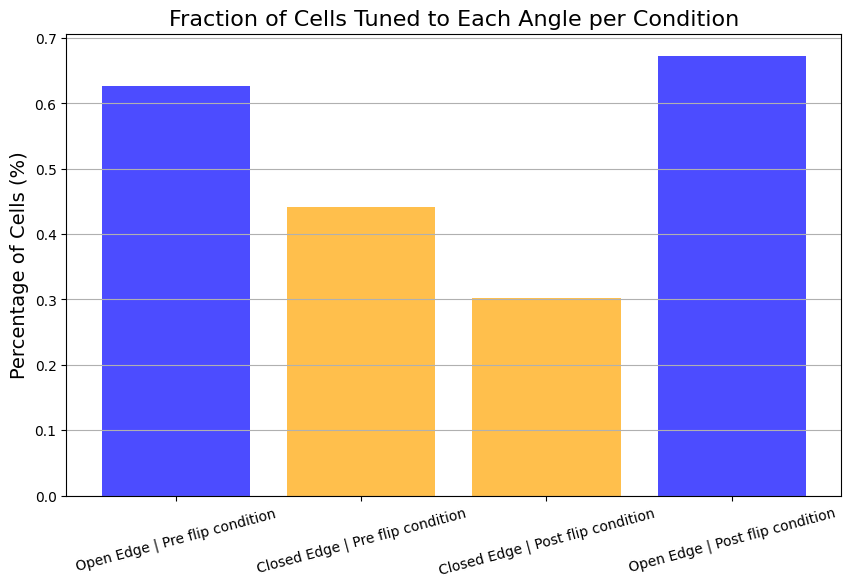

In [8]:
# plot inline
%matplotlib inline
# Plot a bar plot of the fraction of cells tuned to each angle epr condition
x_labels = ['Open Edge | Pre flip condition', 
            'Closed Edge | Pre flip condition', 
            'Closed Edge | Post flip condition', 
            'Open Edge | Post flip condition']
open_edge_pre = summary_total_df.loc[summary_total_df['condition'] == 'barrier_pre_flip', 'pct_pre_over_total'].values[0]
closed_edge_pre = summary_total_df.loc[summary_total_df['condition'] == 'barrier_pre_flip', 'pct_post_over_total'].values[0]
open_edge_post = summary_total_df.loc[summary_total_df['condition'] == 'barrier_post_flip', 'pct_post_over_total'].values[0]
closed_edge_post = summary_total_df.loc[summary_total_df['condition'] == 'barrier_post_flip', 'pct_pre_over_total'].values[0]
plt.figure(figsize=(10, 6))
plt.bar(x_labels, [open_edge_pre, closed_edge_pre, closed_edge_post, open_edge_post], color=['blue', 'orange', 'orange', 'blue'], alpha=0.7)
plt.ylabel('Percentage of Cells (%)', fontsize=14)
plt.title('Fraction of Cells Tuned to Each Angle per Condition', fontsize=16)
plt.xticks(rotation=15)
plt.grid(axis='y')
plt.show()

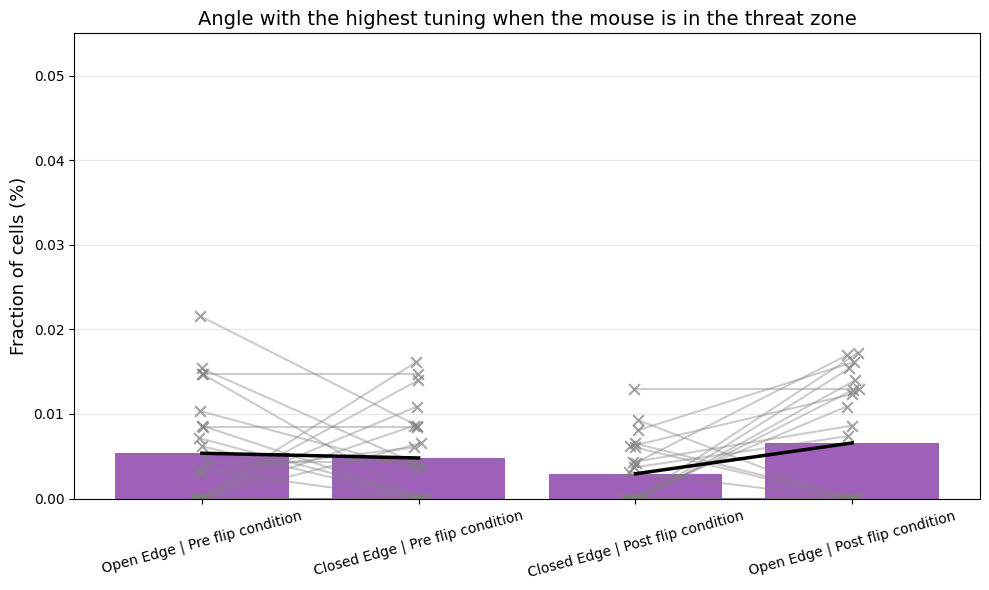

In [9]:
# --- 1) Build per-session summary -------------------------------------------
import pandas as pd

target_conditions = ["barrier_pre_flip", "barrier_post_flip"]
angle_labels_of_interest = ["h_preflipbar_a", "h_postflipbar_a"]

# counts_by_session[session][condition] -> dict of totals and angle counts
counts_by_session = {}

for session, cell_dict in loaded_threat_dict.items():
    if session not in counts_by_session:
        counts_by_session[session] = {c: {"total_cells": 0,
                                          "tuned_cells": 0,
                                          "h_preflipbar_a": 0,
                                          "h_postflipbar_a": 0}
                                      for c in target_conditions}
    for cluster_id, cond_dict in cell_dict.items():
        for cond in target_conditions:
            if cond not in cond_dict:
                continue
            counts_by_session[session][cond]["total_cells"] += 1
            entry = cond_dict[cond]

            if entry == "Not tuned" or entry is None:
                continue
            if not isinstance(entry, (list, tuple)) or len(entry) == 0:
                continue

            try:
                max_angle, max_val = max(entry, key=lambda x: x[1])
            except Exception:
                continue

            counts_by_session[session][cond]["tuned_cells"] += 1
            if max_angle in angle_labels_of_interest:
                counts_by_session[session][cond][max_angle] += 1

# Build per-session rows
session_rows = []
for session, conds in counts_by_session.items():
    for cond, c in conds.items():
        tot = c["total_cells"] if c["total_cells"] else 0
        pre_n  = c["h_preflipbar_a"]
        post_n = c["h_postflipbar_a"]
        session_rows.append({
            "session": session,
            "condition": cond,
            "total_cells": tot,
            "h_preflipbar_a_count": pre_n,
            "h_postflipbar_a_count": post_n,
            "pct_pre_over_total":  (pre_n  / tot) if tot else 0.0,
            "pct_post_over_total": (post_n / tot) if tot else 0.0
        })

session_summary_df = pd.DataFrame(session_rows)

# --- 2) Compute group means for the four bars (unweighted mean across sessions)
def mean_or_zero(s): 
    return float(s.mean()) if len(s) else 0.0

# Map to the 4 plotting slots:
# slot 0 = Open Edge | Pre flip        -> barrier_pre_flip,  pct_pre_over_total
# slot 1 = Closed Edge | Pre flip      -> barrier_pre_flip,  pct_post_over_total
# slot 2 = Closed Edge | Post flip     -> barrier_post_flip, pct_pre_over_total
# slot 3 = Open Edge | Post flip       -> barrier_post_flip, pct_post_over_total
bar_means = [
    mean_or_zero(session_summary_df.query("condition=='barrier_pre_flip'")["pct_pre_over_total"]),
    mean_or_zero(session_summary_df.query("condition=='barrier_pre_flip'")["pct_post_over_total"]),
    mean_or_zero(session_summary_df.query("condition=='barrier_post_flip'")["pct_pre_over_total"]),
    mean_or_zero(session_summary_df.query("condition=='barrier_post_flip'")["pct_post_over_total"]),
]

# --- 3) Plot bars + per-session points with lines ----------------------------
import matplotlib.pyplot as plt
import numpy as np

x_labels = [
    'Open Edge | Pre flip condition',
    'Closed Edge | Pre flip condition',
    'Closed Edge | Post flip condition',
    'Open Edge | Post flip condition'
]
x = np.arange(4)

plt.figure(figsize=(10, 6))
# Purple bars (group means)
plt.bar(x, bar_means, color='#8e44ad', alpha=0.85)

# Overlay per-session points and connect pairs
# jitter to avoid perfect overlap of x's
rng = np.random.default_rng(7)

for session in session_summary_df["session"].unique():
    sub = session_summary_df[session_summary_df["session"] == session]

    # Get the four y-values for this session (may be missing if session lacks a condition)
    y0 = sub.loc[sub["condition"]=="barrier_pre_flip",  "pct_pre_over_total"]
    y1 = sub.loc[sub["condition"]=="barrier_pre_flip",  "pct_post_over_total"]
    y2 = sub.loc[sub["condition"]=="barrier_post_flip", "pct_pre_over_total"]
    y3 = sub.loc[sub["condition"]=="barrier_post_flip", "pct_post_over_total"]

    # default to NaN if missing
    y0 = float(y0.iloc[0]) if len(y0) else np.nan
    y1 = float(y1.iloc[0]) if len(y1) else np.nan
    y2 = float(y2.iloc[0]) if len(y2) else np.nan
    y3 = float(y3.iloc[0]) if len(y3) else np.nan

    xs = x + rng.normal(0, 0.02, size=4)  # tiny jitter
    ys = [y0, y1, y2, y3]

    # Scatter points for each bar
    plt.scatter(xs, ys, marker='x', s=60, linewidths=1.5, color='gray', alpha=0.7)

    # Connect within the pairs:
    # Pre pair: slot 0 -> slot 1
    if np.isfinite(y0) and np.isfinite(y1):
        plt.plot([xs[0], xs[1]], [y0, y1], color='gray', alpha=0.4, linewidth=1.5)
    # Post pair: slot 2 -> slot 3
    if np.isfinite(y2) and np.isfinite(y3):
        plt.plot([xs[2], xs[3]], [y2, y3], color='gray', alpha=0.4, linewidth=1.5)

# Optionally, draw bold lines linking the group means within each pair (for emphasis)
plt.plot([x[0], x[1]], [bar_means[0], bar_means[1]], color='black', linewidth=2.5)
plt.plot([x[2], x[3]], [bar_means[2], bar_means[3]], color='black', linewidth=2.5)

plt.ylabel('Fraction of cells (%)', fontsize=13)
plt.title('Angle with the highest tuning when the mouse is in the threat zone', fontsize=14)
plt.xticks(x, x_labels, rotation=15)
plt.ylim(0, max(bar_means + [*session_summary_df["pct_pre_over_total"], *session_summary_df["pct_post_over_total"]]) * 1.25 if len(session_summary_df) else 1)
plt.ylim(0, 0.055)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


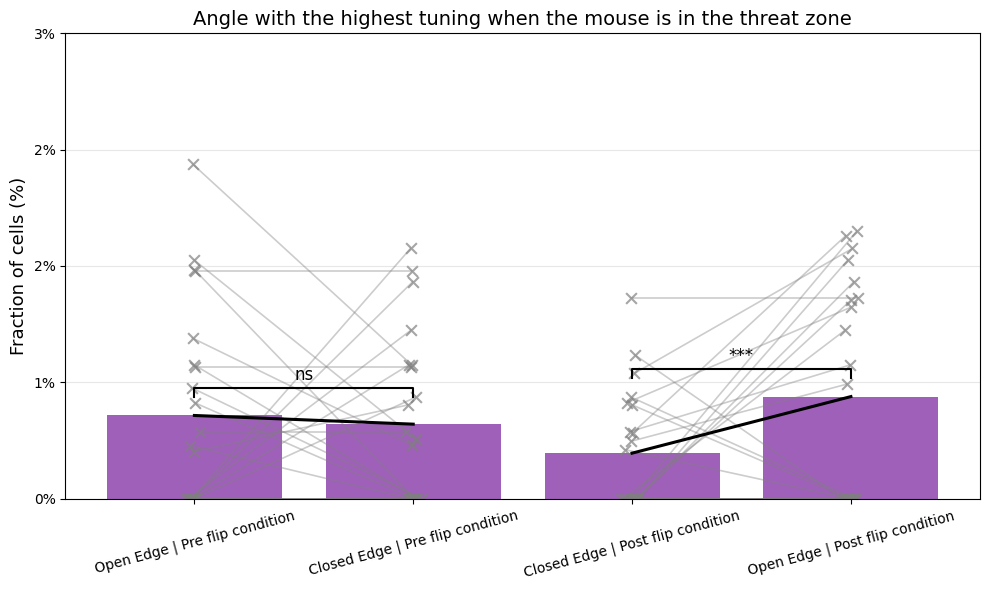

In [10]:
# === 4) Plot with dynamic % y-axis =========================================
from matplotlib.ticker import FuncFormatter

def add_sig_bar(ax, x1, x2, top_y, p_val, frac_pad):
    """Draw a significance bar with padding relative to y-range (fraction units)."""
    if np.isnan(p_val):
        text = "n/a"
    elif p_val < 0.001:
        text = "***"
    elif p_val < 0.01:
        text = "**"
    elif p_val < 0.05:
        text = "*"
    else:
        text = "ns"
    y = top_y + frac_pad
    ax.plot([x1, x1, x2, x2], [y, y+frac_pad*0.5, y+frac_pad*0.5, y], lw=1.5, color='k')
    ax.text((x1 + x2) / 2, y + frac_pad*0.7, text, ha='center', va='bottom', fontsize=12)

fig, ax = plt.subplots(figsize=(10, 6))

# Bars = group means (fractions)
ax.bar(x, bar_means, color='#8e44ad', alpha=0.85)

# Session scatter + connecting lines
rng = np.random.default_rng(7)
all_session_vals = []
for session in session_summary_df["session"].unique():
    sub = session_summary_df[session_summary_df["session"] == session]
    def pull(cond, col):
        v = sub.loc[sub["condition"]==cond, col]
        return float(v.iloc[0]) if len(v) else np.nan
    y0 = pull("barrier_pre_flip",  "pct_pre_over_total")   # Open | Pre
    y1 = pull("barrier_pre_flip",  "pct_post_over_total")  # Closed | Pre
    y2 = pull("barrier_post_flip", "pct_pre_over_total")   # Closed | Post
    y3 = pull("barrier_post_flip", "pct_post_over_total")  # Open | Post
    xs = x + rng.normal(0, 0.02, size=4)
    ys = np.array([y0, y1, y2, y3], dtype=float)
    all_session_vals.extend(ys[np.isfinite(ys)].tolist())

    ax.scatter(xs, ys, marker='x', s=60, linewidths=1.5, color='gray', alpha=0.7)
    if np.isfinite(y0) and np.isfinite(y1):
        ax.plot([xs[0], xs[1]], [y0, y1], color='gray', alpha=0.4, linewidth=1.2)
    if np.isfinite(y2) and np.isfinite(y3):
        ax.plot([xs[2], xs[3]], [y2, y3], color='gray', alpha=0.4, linewidth=1.2)

# Bold mean-connecting lines for pairs
ax.plot([x[0], x[1]], [bar_means[0], bar_means[1]], color='black', linewidth=2.2)
ax.plot([x[2], x[3]], [bar_means[2], bar_means[3]], color='black', linewidth=2.2)

# ----- Dynamic y-limit in FRACTIONS ----------------------------------------
vals_for_limit = np.array(bar_means + all_session_vals, dtype=float)
vals_for_limit = vals_for_limit[np.isfinite(vals_for_limit)]
ymax = float(vals_for_limit.max()) if vals_for_limit.size else 0.05  # fallback

# Add headroom; clamp to something reasonable if extremely tiny
y_top = max(0.03, ymax * 1.35)          # at least 3%
y_top = min(y_top, 0.25) if y_top > 0.25 else y_top  # cap at 25% if unusually large

# y-axis as percent but keep data as fractions
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y*100:.0f}%'))
ax.set_ylim(0, y_top)
# 5–6 ticks looks nice
ticks = np.linspace(0, y_top, 6 if y_top >= 0.05 else 5)
ax.set_yticks(ticks)

# Labels
ax.set_ylabel('Fraction of cells (%)', fontsize=13)
ax.set_title('Angle with the highest tuning when the mouse is in the threat zone', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=15)
ax.grid(axis='y', alpha=0.3)

# Significance bars (pad relative to axis height)
pad = 0.04 * y_top  # 4% of axis range
add_sig_bar(ax, 0, 1, max(bar_means[0], bar_means[1]), pre_n, pad)
add_sig_bar(ax, 2, 3, max(bar_means[2], bar_means[3]), post_n, pad)

plt.tight_layout()
plt.show()
